# Machine Learning Assignment 2: Classification Models & Evaluation
**Student ID**: 2025AC05718  
**Course**: Machine Learning (M.Tech AIML/DSE)  
**Dataset**: UCI Heart Disease Classification Dataset (1,025 instances, 13 features)

In [6]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

## 1. Load Dataset

In [7]:
# Load dataset from parent directory
data_path = '../heart_disease_dataset.csv' if os.path.exists('../heart_disease_dataset.csv') else 'heart_disease_dataset.csv'
df = pd.read_csv(data_path)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48,0,1,106,553,0,0,179,0,2.0,2,1,2,0
1,42,0,0,196,409,1,1,151,1,2.6,1,0,3,0
2,70,1,0,157,184,0,1,135,0,0.4,2,0,2,1
3,60,1,1,120,506,0,0,121,0,2.7,1,0,1,0
4,45,1,1,165,466,0,1,193,0,0.9,2,0,3,0


## 2. Train-Test Split (80/20) & Feature Standardization

In [8]:
X = df.drop(columns=['target'])
y = df['target']

# 80-20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save fitted scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Training instances:", len(X_train))
print("Testing instances:", len(X_test))
print("Saved scaler.pkl successfully!")

Training instances: 820
Testing instances: 205
Saved scaler.pkl successfully!


## 3. Train 5 Classification Models & Export Pickle Binaries

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
    'Random Forest (Ensemble)': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
}

file_mapping = {
    'Logistic Regression': 'logistic_regression.pkl',
    'Decision Tree': 'decision_tree.pkl',
    'kNN': 'knn.pkl',
    'Naive Bayes': 'naive_bayes.pkl',
    'Random Forest (Ensemble)': 'random_forest.pkl'
}

results = []

for name, clf in models.items():
    if name in ['Logistic Regression', 'kNN', 'Naive Bayes']:
        clf.fit(X_train_scaled, y_train)
        preds = clf.predict(X_test_scaled)
        probs = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        probs = clf.predict_proba(X_test)[:, 1]
        
    # Save trained pickle binary
    with open(file_mapping[name], 'wb') as f:
        pickle.dump(clf, f)
        
    results.append({
        'ML Model Name': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'AUC': round(roc_auc_score(y_test, probs), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall': round(recall_score(y_test, preds, zero_division=0), 4),
        'F1': round(f1_score(y_test, preds, zero_division=0), 4),
        'MCC': round(matthews_corrcoef(y_test, preds), 4)
    })

results_df = pd.DataFrame(results)
results_df.to_json('metrics_summary.json', orient='records')
print("All 5 model .pkl binaries and metrics_summary.json saved!")
results_df

All 5 model .pkl binaries and metrics_summary.json saved!


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9951,1.0000,1.0000,0.9643,0.9818,0.9792
1,Decision Tree,0.9073,0.7336,0.7143,0.5357,0.6122,0.5683
2,kNN,0.9268,0.9459,0.8824,0.5357,0.6667,0.6530
3,Naive Bayes,0.9268,0.9514,0.8824,0.5357,0.6667,0.6530
4,Random Forest (Ensemble),0.9122,0.9679,1.0000,0.3571,0.5263,0.5694


## 4. Visualizations: Confusion Matrix & Classification Report

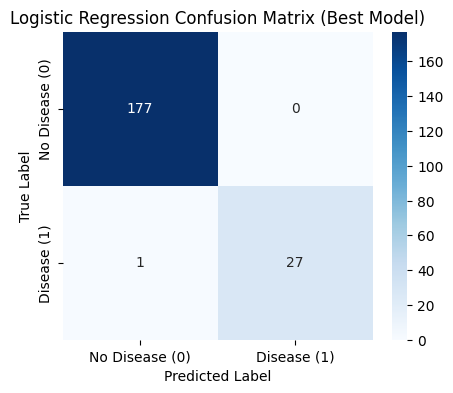


Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       177
           1       1.00      0.96      0.98        28

    accuracy                           1.00       205
   macro avg       1.00      0.98      0.99       205
weighted avg       1.00      1.00      1.00       205



In [10]:
lr = models['Logistic Regression']
lr_preds = lr.predict(X_test_scaled)
cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix (Best Model)')
plt.show()

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, lr_preds))